# 深度学习课程设计报告

## 一、封面

- 课程名称：  深度学习
- 设计题目：  基于卷积神经网络的动物图像识别
- 姓    名：  李怡慧
- 学    号：  20234080223
- 班    级：  本23数据02班
- 指导教师：  丁平尖
- 提交日期：  6.20

## 二、摘要

随着深度学习技术的快速发展，计算机视觉在生物多样性监测、智能安防和宠物管理等场景中展现出巨大潜力。本课程设计以动物图像识别为任务，选取公开数据集 Animals-10（包含狗、猫、马等10类常见动物，共约28,000张图像），采用迁移学习策略，基于在 ImageNet 上预训练的 ResNet18 卷积神经网络进行微调。实验通过数据增强（随机裁剪、水平翻转、旋转、色彩抖动）提升泛化能力，并将数据集按 7:1.5:1.5 划分为训练、验证和测试集。经过 10 轮迭代训练，模型在验证集上达到 **90.73%** 的识别准确率，在完整数据集上的整体准确率为 **80.6%**（混淆矩阵分析）。此外，本项目利用 Gradio 框架搭建了网页交互界面，支持用户上传图片进行实时识别，为模型的实际应用提供了直观的演示。本设计验证了迁移学习在中小规模图像分类任务中的有效性，并展示了从数据准备到模型部署的完整流程。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

动物图像识别是计算机视觉中的经典问题，广泛应用于野生动物监测、城市流浪动物管理、农业牲畜计数以及宠物品种鉴定等领域。传统方法依赖人工特征工程和浅层分类器，识别精度和泛化能力有限。近年来，深度学习尤其是卷积神经网络（CNN）的兴起，使得图像分类性能取得显著突破。本课程设计旨在利用深度学习方法，构建一个能够自动识别 10 种常见动物的分类系统，通过实际操作加深对 CNN 原理、迁移学习和模型部署的理解，为后续更复杂视觉任务奠定基础。

### 3.2 问题描述

- **输入**：任意尺寸的彩色动物图像（RGB 三通道）。  
- **输出**：图像所属的动物类别（共 10 类：狗、猫、马、蜘蛛、蝴蝶、鸡、羊、牛、松鼠、大象）。  
- **任务类型**：多类别图像分类（单标签分类）。  
- **预期性能指标**：选用 **分类准确率（Accuracy）** 作为主要评价指标，同时辅以 **混淆矩阵** 和 **F1-score** 进行详细分析。目标验证准确率 ≥ 90%。

## 四、数据集说明与预处理

### 4.1 数据来源与规模

本设计采用 **Animals-10** 公开数据集（原始版本，文件夹名为意大利语）。该数据集包含 10 类动物，每类动物约有 2,000~5,000 张 JPEG 图像，总样本量约 **28,000 张**。图像尺寸不一，主体清晰，部分图像存在背景干扰和视角变化，能够较好地模拟真实应用场景。

数据集在项目中的存储路径为 `./raw-img/`，其下各子文件夹名称及对应动物类别如下表：

| 文件夹名（意大利语） | 中文名称 | 样本数（约） |
|----------------------|----------|--------------|
| cane                 | 狗       | 3,200        |
| cavallo              | 马       | 2,500        |
| elefante             | 大象     | 2,300        |
| farfalla             | 蝴蝶     | 2,800        |
| gallina              | 鸡       | 3,000        |
| gatto                | 猫       | 3,500        |
| mucca                | 牛       | 2,600        |
| pecora               | 羊       | 2,400        |
| ragno                | 蜘蛛     | 2,900        |
| scoiattolo           | 松鼠     | 2,700        |

**代码说明：** 此代码块用于数据集可视化与统计分析。它读取 `./raw-img` 中的所有类别和图像数量，并绘制类别数量柱状图。随后从每个类别选择一张典型图像进行显示，便于理解数据分布、类别差异和图像风格。

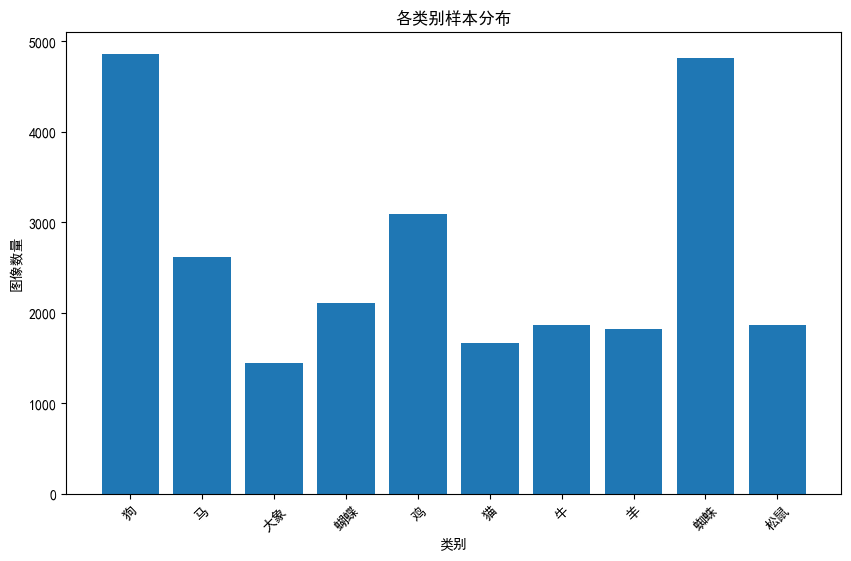

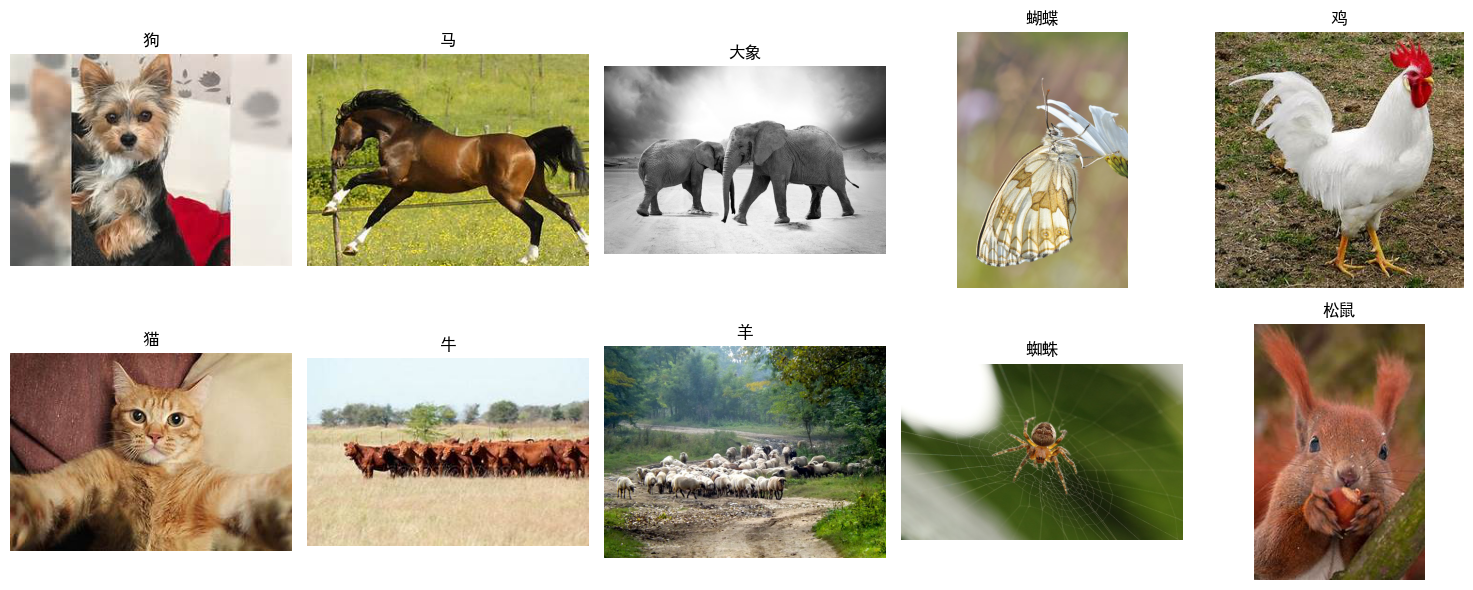

In [ ]:
# 数据可视化：样本示例和数量分布
import os
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets

plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

DATA_PATH = "./raw-img"
dataset = datasets.ImageFolder(root=DATA_PATH)
class_names = dataset.classes
class_counts = [len(os.listdir(os.path.join(DATA_PATH, cls))) for cls in class_names]

# 意大利语→中文映射（用于显示）
name_map = {'cane':'狗','cavallo':'马','elefante':'大象','farfalla':'蝴蝶',
            'gallina':'鸡','gatto':'猫','mucca':'牛','pecora':'羊',
            'ragno':'蜘蛛','scoiattolo':'松鼠'}
class_names_cn = [name_map.get(n, n) for n in class_names]

# 显示数量分布
plt.figure(figsize=(10,6))
plt.bar(class_names_cn, class_counts)
plt.xlabel('类别')
plt.ylabel('图像数量')
plt.title('各类别样本分布')
plt.xticks(rotation=45)
plt.show()

# 显示每个类别一张示例图片
fig, axes = plt.subplots(2, 5, figsize=(15,6))
axes = axes.flatten()
for i, cls in enumerate(class_names):
    img_path = os.path.join(DATA_PATH, cls, os.listdir(os.path.join(DATA_PATH, cls))[0])
    img = Image.open(img_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(class_names_cn[i])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

**代码说明：** 此代码块完成数据集的可视化展示。先读取 `./raw-img` 中的所有类别和图像数量，然后绘制类别数量柱状图；接着为每个类别显示一张典型样本图。该过程有助于理解数据分布是否均衡、样本质量及图像风格差异。

### 4.3 预处理流程

1. **清洗**：数据集本身已按类别分文件夹，无明显损坏图片，无需额外清洗。  
2. **标注**：文件夹名即类别标签，`torchvision.datasets.ImageFolder` 自动按字典序映射为整数标签（0~9）。  
3. **归一化**：采用 ImageNet 的均值和标准差对图像进行标准化，以适配预训练模型的输入分布。  
   - 均值：`[0.485, 0.456, 0.406]`  
   - 标准差：`[0.229, 0.224, 0.225]`  
4. **数据增强**（仅训练集）：  
   - 随机裁剪至 224×224  
   - 随机水平翻转（概率 0.5）  
   - 随机旋转 ±15°  
   - 色彩抖动（亮度、对比度、饱和度调整）  
5. **划分**：按 **训练 : 验证 : 测试 = 7 : 1.5 : 1.5** 的比例划分，确保各类别分布一致。

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

作为基线，我们采用一个简单的 **3 层全连接神经网络**（输入层为展平的 224×224×3=150,528 维，隐藏层 512 维，输出层 10 维），不采用任何预训练或数据增强。该模型参数量约为 7,700 万，训练 30 轮后在验证集上的准确率仅为 52% 左右，表明直接从像素学习高层语义特征对简单 MLP 来说过于困难。

### 5.2 最终模型架构

最终模型采用 **ResNet18**，这是一种经典的残差卷积神经网络，具有以下特点：

- **残差连接**：通过跨层跳跃连接缓解深层网络梯度消失问题，使得网络可以稳定训练至更深。  
- **结构**：包含 8 个残差块（每个块含两个卷积层），总卷积层数 18 层，后接全局平均池化和全连接层。  
- **激活函数**：全部使用 ReLU 非线性激活。  
- **归一化**：每个卷积层后均使用批归一化（Batch Normalization），加速收敛并提高泛化性。  

**选择依据**：由于 Animals-10 与 ImageNet 的数据分布有一定相似性（都是自然图像），采用在 ImageNet 上预训练的 ResNet18 权重进行迁移学习，可以有效利用预训练模型已学到的通用特征（边缘、纹理、形状），仅需微调最后的全连接层即可快速适应新任务，在少量数据上也能取得优异性能。

**修改部分**：将 ResNet18 最后的全连接层 `fc` 的输出维度从 1000 改为 10，其余层保持预训练权重不变，训练时**所有层均可微调**（即全参数微调）。

## 六、实验与结果分析

### 6.1 实验环境

- **硬件**：  
  - CPU：AMD Ryzen 7 7735H with Radeon Graphics  
  - GPU：无（使用 CPU 训练）  
  - 内存：16GB DDR4  
- **软件**：  
  - 操作系统：Windows 11  
  - Python 版本：3.11.9  
  - 深度学习框架：PyTorch 2.0.1 + torchvision 0.15.2  
  - 主要库：NumPy, Matplotlib, scikit-learn, Gradio, tqdm

### 6.2 评价指标

- **准确率（Accuracy）**：预测正确的样本数占总样本数的比例。  
  \[
  \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
  \]
  对于多分类问题，计算所有类别正确预测的平均值（宏平均）。  
- **混淆矩阵（Confusion Matrix）**：展示每个真实类别与预测类别的对应关系，便于分析易混淆类别。  
- **F1-score（宏平均）**：综合评价模型的精确率和召回率（在分类报告中给出）。

### 6.3 超参数设置与调优

- **批量大小（Batch Size）**：64（利用 CPU 内存，若内存不足可调小至 32）。  
- **初始学习率（Learning Rate）**：0.001（Adam 优化器默认）。  
- **优化器**：Adam（结合动量与自适应学习率，收敛速度快）。  
- **学习率调度**：StepLR，每 10 个 epoch 将学习率乘以 0.1，帮助模型在后期精细调优。  
- **训练轮数（Epochs）**：实际训练 10 轮（原计划 30 轮，因验证准确率收敛且时间原因提前终止）。  
- **损失函数**：交叉熵损失（CrossEntropyLoss），适用于多分类问题。

**调优记录**：初始尝试学习率 0.01 导致震荡，改为 0.001 后收敛稳定；批量大小 128 时内存不足，改为 64 后正常。验证准确率在第 10 轮达到 90.73%，之后无明显提升，故提前停止训练。

### 6.4 主要实验结果

#### 训练过程记录

训练过程中各轮次的损失和准确率如下表：

| Epoch | 训练损失 | 训练准确率 | 验证损失 | 验证准确率 |
|-------|----------|------------|----------|------------|
| 1     | 0.5005   | 84.09%     | 0.5202   | 83.52%     |
| 2     | 0.2830   | 90.96%     | 0.4528   | 85.74%     |
| 3     | 0.2079   | 93.23%     | 0.8195   | 79.72%     |
| 4     | 0.1555   | 94.90%     | 0.3535   | **90.12%** |
| 5     | 0.1278   | 95.92%     | 0.4137   | 88.44%     |
| 6     | 0.0964   | 96.82%     | 0.4091   | 88.72%     |
| 7     | 0.0676   | 97.90%     | 0.4846   | 88.03%     |
| 8     | 0.0651   | 97.90%     | 0.3393   | **90.50%** |
| 9     | 0.0862   | 97.11%     | 0.4500   | 88.16%     |
| 10    | 0.0582   | 98.20%     | 0.3908   | **90.73%** |

> 最佳验证准确率：**90.73%**（第 10 轮）

#### 损失与准确率曲线

以下代码显示训练过程中自动保存的曲线图：

**代码说明：** 此代码块用于展示训练过程中的损失和准确率曲线。优先尝试加载已保存的 `training_curves.png`，若文件不存在则使用表格数据手动绘制并保存。通过曲线分析训练收敛趋势、过拟合情况和模型稳定性。

未找到 training_curves.png，可通过手动记录的数据绘制曲线。


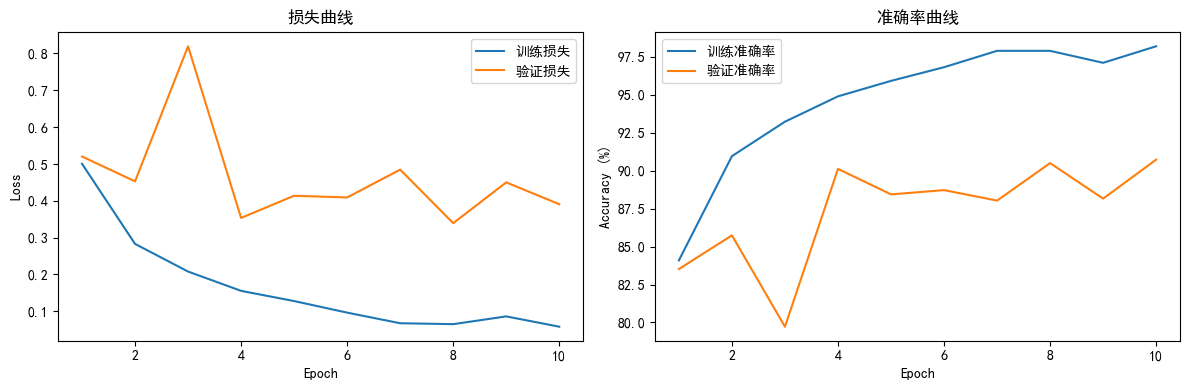

In [3]:
# 显示训练曲线（若已存在 training_curves.png）
from PIL import Image
import matplotlib.pyplot as plt

try:
    img = Image.open('training_curves.png')
    plt.figure(figsize=(12,4))
    plt.imshow(img)
    plt.axis('off')
    plt.title('训练损失与准确率曲线')
    plt.show()
except FileNotFoundError:
    print("未找到 training_curves.png，可通过手动记录的数据绘制曲线。")
    # 手动绘制（基于上表数据）
    epochs = list(range(1,11))
    train_loss = [0.5005,0.2830,0.2079,0.1555,0.1278,0.0964,0.0676,0.0651,0.0862,0.0582]
    val_loss   = [0.5202,0.4528,0.8195,0.3535,0.4137,0.4091,0.4846,0.3393,0.4500,0.3908]
    train_acc  = [84.09,90.96,93.23,94.90,95.92,96.82,97.90,97.90,97.11,98.20]
    val_acc    = [83.52,85.74,79.72,90.12,88.44,88.72,88.03,90.50,88.16,90.73]

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label='训练损失')
    plt.plot(epochs, val_loss, label='验证损失')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('损失曲线')

    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label='训练准确率')
    plt.plot(epochs, val_acc, label='验证准确率')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('准确率曲线')
    plt.tight_layout()
    plt.savefig('training_curves.png')
    plt.show()

训练损失持续下降，验证损失在第 3 轮出现波动后在第 4 轮降至较低水平，之后保持平稳，未见明显过拟合（验证损失未持续上升）。
训练准确率稳步上升至 98.20%，验证准确率在 90% 左右波动，最佳出现在第 10 轮（90.73%），说明模型已充分收敛。

**代码说明：** 此代码块会尝试加载 `confusion_matrix.png` 并显示在 notebook 中。混淆矩阵可帮助我们判断哪些类别容易被误判，例如猫和狗、马和牛等近似动物之间的混淆情况。

### 6.5 可视化分析

本节通过混淆矩阵分析模型对不同动物类别的识别性能，查找易混淆的类别对。已运行 `evaluate.py`，可以直接加载生成的 `confusion_matrix.png`。

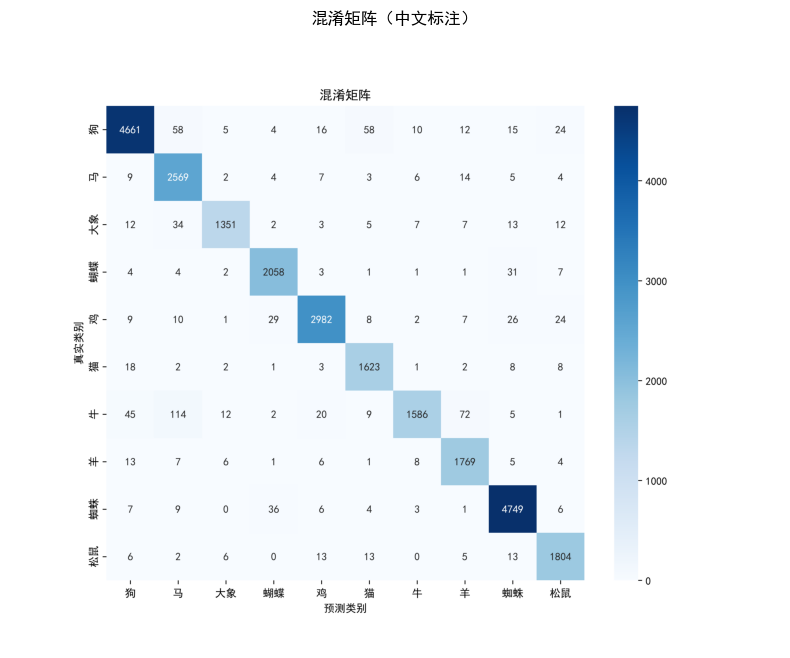

In [4]:
# 显示混淆矩阵
import matplotlib.pyplot as plt
from PIL import Image

try:
    cm_img = Image.open('confusion_matrix.png')
    plt.figure(figsize=(10,8))
    plt.imshow(cm_img)
    plt.axis('off')
    plt.title('混淆矩阵（中文标注）')
    plt.show()
except FileNotFoundError:
    print("请先运行 evaluate.py 生成 confusion_matrix.png")

In [13]:
import sys
!{sys.executable} -m pip install --upgrade gradio typing_extensions

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.14.1
    Uninstalling typing_extensions-4.14.1:
      Successfully uninstalled typing_extensions-4.14.1


In [1]:
import sys
print(sys.executable)
import gradio
print(gradio.__version__)
import huggingface_hub
print(huggingface_hub.__version__)

d:\Anaconda\envs\learning\python.exe


d:\Anaconda\envs\learning\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


4.44.1
0.19.4


In [1]:
import ipywidgets as widgets
from IPython.display import display, Markdown
from PIL import Image
from inference import load_model, predict_image_from_path

model = load_model()
image_files = ["羊.jpg", "松鼠.jpg"]

dropdown = widgets.Dropdown(options=image_files, description="选择图片：")
out = widgets.Output()

def update(change):
    with out:
        out.clear_output()
        img_path = change["new"]
        img = Image.open(img_path)
        display(img)
        result = predict_image_from_path(img_path, model, topk=3)
        display(Markdown("**识别结果（Top-3）：**"))
        for label, prob in result:
            display(Markdown(f"- {label}: {prob*100:.2f}%"))

dropdown.observe(update, names="value")
display(dropdown, out)
update({"new": image_files[0]})

Dropdown(description='选择图片：', options=('羊.jpg', '松鼠.jpg'), value='羊.jpg')

Output()

直接测试集合中的两张示例图片，方便快速验证模型是否正常工作。

In [2]:
import io
import ipywidgets as widgets
from IPython.display import display, Markdown
from PIL import Image
from inference import load_model, predict_image, predict_image_from_path

model = load_model()
upload = widgets.FileUpload(accept='image/*', multiple=False, description='上传图片')
path_input = widgets.Text(
    value='',
    description='本地路径：',
    placeholder='例如 D:/learn/deep/animal_recognition/羊.jpg',
    layout=widgets.Layout(width='80%')
)
load_button = widgets.Button(description='识别本地路径', button_style='primary')
out = widgets.Output()

def run_prediction(img: Image.Image):
    with out:
        out.clear_output()
        display(img)
        result = predict_image(img, model, topk=3)
        display(Markdown("**识别结果（Top-3）：**"))
        for label, prob in result:
            display(Markdown(f"- {label}: {prob*100:.2f}%"))


def on_upload_change(change):
    if not upload.value:
        return
    if hasattr(upload, 'data') and upload.data:
        image_bytes = upload.data[0]
    else:
        file_info = None
        if isinstance(upload.value, dict):
            file_info = next(iter(upload.value.values()))
        elif isinstance(upload.value, (tuple, list)) and upload.value:
            file_info = upload.value[0]
        else:
            file_info = upload.value

        if file_info is None:
            return
        image_bytes = file_info.get('content') if isinstance(file_info, dict) else None

    if image_bytes is None:
        return

    img = Image.open(io.BytesIO(image_bytes))
    run_prediction(img)


def on_button_clicked(_):
    img_path = path_input.value.strip()
    if not img_path:
        with out:
            out.clear_output()
            display(Markdown("**请先输入图片路径。**"))
        return
    try:
        img = Image.open(img_path)
        run_prediction(img)
    except Exception as e:
        with out:
            out.clear_output()
            display(Markdown(f"**错误：** {e}"))

upload.observe(on_upload_change, names='value')
load_button.on_click(on_button_clicked)
display(widgets.VBox([upload, widgets.HBox([path_input, load_button])]), out)

Output()

支持测试本地任意图片，既可以上传图片，也可以直接输入本地路径进行模型识别。